In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as spopt
import numpy.ma as ma
from tqdm import tqdm
import pandas as pd
import glob, os
from astropy.time import Time
import sys
from matplotlib.patches import Rectangle
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import NullLocator
from matplotlib.ticker import FixedLocator

In [2]:
#We are going full Claude mode with the legend here - This is only for the burst detection in red and black
#Claude provided me with this code and it worked immediately.
#Ask Claude what is does, cause I knew one day, but only Claude and God know what is does now.
from matplotlib.legend_handler import HandlerBase

class HalfHalfHandler(HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        left  = Rectangle((xdescent,             ydescent), width / 2, height, facecolor='k',   transform=trans)
        right = Rectangle((xdescent + width / 2, ydescent), width / 2, height, facecolor='red', transform=trans)
        return [left, right]

class HalfHalfPatch:
    def __init__(self, label):
        self._label = label

    def get_label(self):
        return self._label

In [3]:
def get_station_colors():
    cols = ['#4dac26', '#377eb8', '#e66101', 'darkorchid', 'black', '#e7298a']
    return {'on': cols[0], 'wb': cols[1], 'tr': cols[2], 'st': cols[3], 'fast': cols[4], 'dw':cols[5]}

In [5]:
def fluence_hyperflash_loader(csv_file):
    
    fluence_df = pd.read_csv(csv_file, index_col=0)
    fluence_df = fluence_df[["id", "toa", "fluence", "bandwidth", "central frequency", "2bit-wb-tag"]].rename(columns={"central frequency": "cent_freq"})
    fluence_df = fluence_df.dropna(subset=["toa"])
    fluence_df["burst-index"] = fluence_df['id'].str.split('-').str[0].str[1:].astype(int)
    fluence_df["telescope"] = fluence_df['id'].str.split('-').str[1].astype(str)
    fluence_df = fluence_df.sort_values(by=['toa'])
    fluence_df = fluence_df.reset_index(drop=True)

    # Drop duplicate burst-index, keep first
    fluence_df = fluence_df.drop_duplicates(subset=['burst-index'], keep='first')

    # 5-hour window averaging of toa, protecting the special burst
    special_mjd = 60586.95765262046
    window_days = 2 / 24.0

    groups = []
    used = set()
    for i, row in fluence_df.iterrows():
        if i in used:
            continue
        # Never merge the special burst or P-band bursts with others
        if abs(row['toa'] - special_mjd) < 1e-1 or row['cent_freq'] < 400:
            groups.append(row)
            used.add(i)
            continue
        # Find all bursts within 5 hours of this one (excluding special)
        mask = (
            (fluence_df['toa'] - row['toa']).abs() <= window_days) & \
            (~fluence_df.index.isin(used)) & \
            (fluence_df['toa'].sub(special_mjd).abs() >= 1e-6) & \
            (fluence_df['cent_freq'] >= 400
        )
        window = fluence_df[mask]
        merged = row.copy()
        merged['toa'] = window['toa'].mean()
        groups.append(merged)
        used.update(window.index.tolist())

    fluence_df = pd.DataFrame(groups).reset_index(drop=True)
    fluence_df = fluence_df.sort_values(by=['fluence']).reset_index(drop=True)

    return fluence_df

df_mjds = fluence_hyperflash_loader(csv_file="../databases/FRB20240114A_HyperFlash_paper_table_v2.csv")
display(df_mjds)

,id,toa,fluence,bandwidth,cent_freq,2bit-wb-tag,burst-index,telescope
0,B123-wb,60424.432518,6.09,78.0,1271.0,0.0,123,wb
1,B174-tr,60812.210321,6.23,128.0,1444.0,0.0,174,tr
2,B168-tr,60805.311487,6.23,128.0,1444.0,0.0,168,tr
3,B138-tr,60654.792675,6.79,128.0,1444.0,0.0,138,tr
4,B180-tr,60819.332590,7.22,95.0,1444.0,0.0,180,tr
...,...,...,...,...,...,...,...,...
101,B136-wb,60581.877497,211.15,83.0,1271.0,0.0,136,wb
102,B102-st,60383.264408,530.21,98.0,1381.0,0.0,102,st
103,B125-o8,60431.437166,554.49,85.0,1424.0,0.0,125,o8
104,B141-tr,60674.669724,805.41,128.0,1444.0,0.0,141,tr


In [5]:
def dummy_maker(telescope, obs_code, df_temp):
    #"Function to make an overview of begin, end and frequency setup per observations"
    #"duplicates are allowed in this df"

    dummy_data = {}
    dummy_data["Telescope"] = telescope
    dummy_data["obs_code"] = obs_code

    dummy_data["mjd_start"] = np.min(df_temp["MJD_start_time"])
    dummy_data["mjd_end"] = np.max(df_temp["MJD_end_time"])

    bandwidth = df_temp["Total_Bandwidth_(MHz)"].values[0]
    nchan = df_temp["Number_of_channels"].values[0]

    #Calculate half the channelwidth
    half_channel_width = (bandwidth/nchan) / 2

    #frequency setup of observation
    dummy_data["bandwidth"] = bandwidth
    #dummy_data["nchan"] = nchan

    dummy_data["cent_f"] = df_temp["Central_freq_(MHz)"].values[0]
    dummy_data["low_c_l"] = df_temp["Low_channel_(MHz)"].values[0] - half_channel_width
    dummy_data["high_c_h"] = df_temp["High_channel_(MHz)"].values[0] + half_channel_width

    rec_time_s = np.sum(df_temp["total_obs_time_s"])
    dummy_data["rec_time_s"] = rec_time_s
    dummy_data["rec_time_m"] = rec_time_s / 60.
    dummy_data["rec_time_h"] = rec_time_s / 3600.
    dummy_data["rec_time_d"] = rec_time_s / (3600. * 24.)
    
    return dummy_data

In [6]:
def reduce_df(save_bool=False):
    "Function to load in the main dataframe and reduce to a df which can be used for the making of this plot"
    "This smaller dataframe is based per observation instead of per scan"
    
    big_df = pd.read_csv("..//databases/r147_fullcampaign_V3.csv", sep=",", header=0, index_col=0, \
                            na_values='NA', engine='python')
    big_df = big_df.reset_index(drop=True)
    
    dict_list = []

    #list of all telescopes that were used
    #telescopes2 = list(set(big_df["Telescope"]))
    telescopes = big_df["Telescope"].unique()

    for single_telescope in telescopes:
        big_df_telescope = big_df[(big_df["Telescope"] == single_telescope)]
        
        #list of all the observations code that were used for that specific telescope
        observations = list(set(big_df_telescope["scan_name"]))
        
        #observations.sort()
        for s_observation in observations:
            #Create a temp df for a single telescope for a single observation
            #Even though this df only had source r67, I filter on it as a failsave
            df_temp = big_df_telescope[(big_df_telescope["scan_name"] == s_observation)]

            # some runs have more than one frequency setup, need to account for this
            freqs = df_temp["Central_freq_(MHz)"].unique()
            
            #If there are more than 1 frequency setup in a single observations -- switching frequencies
            if len(df_temp["Central_freq_(MHz)"].unique()) > 1 :

                print(f"!!!Splitting the dataframe {s_observation} because of different frequency setup!!!")
                #When the frequency changes it will get a new numbers in the dataframe, this way we can utilze the groupby method of pandas to loop over the differt dfs
                #example: https://stackoverflow.com/questions/64163984/how-to-split-a-dataframe-each-time-a-string-value-changes-in-a-column
                df_temp['group'] = df_temp['Central_freq_(MHz)'].ne(df_temp['Central_freq_(MHz)'].shift()).cumsum()
                df_temp = df_temp.groupby('group')

                for name, df_temp_freqs in df_temp:

                    dummy_data = dummy_maker(single_telescope, s_observation, df_temp_freqs)
                    dict_list.append(dummy_data)

            else:

                dummy_data = dummy_maker(single_telescope, s_observation, df_temp)
                dict_list.append(dummy_data)
            
    df_reduced = pd.DataFrame(dict_list)    
    df_reduced = df_reduced.sort_values(by="mjd_start")
    df_reduced = df_reduced.reset_index(drop=True)

    uniq = df_reduced["Telescope"].unique()
    print(f"Telescopes in reduced db: {uniq}")
    display(df_reduced)
        
    if save_bool == True:
        csv_obs = "../dbs/r147_camp_reduced_V4.csv"
        df_reduced.to_csv(csv_obs, sep=",", header=True, index=True, na_rep='NA')
        print("reduced campaign saved")
    
    return df_reduced

df_reduced = reduce_df(save_bool=False)

Telescopes in reduced db: ['wb' 'stk' 'tr' 'dw' 'o8']


,Telescope,obs_code,mjd_start,mjd_end,bandwidth,cent_f,low_c_l,high_c_h,rec_time_s,rec_time_m,rec_time_h,rec_time_d
0,wb,pcn239,60338.541678,60338.742083,128.0000,1271.000000,1207.000000,1335.000000,17044.800707,284.080012,4.734667,0.197278
1,wb,pcn240,60339.320058,60339.721016,64.0000,332.000000,300.000000,364.000000,34075.054858,567.917581,9.465293,0.394387
2,stk,r147_60339_1,60339.405731,60339.529175,98.4375,1381.464844,1332.246094,1430.683594,10665.566317,177.759439,2.962657,0.123444
3,stk,r147_60339_2,60339.529182,60339.702688,98.4375,1381.464844,1332.246094,1430.683594,14990.931832,249.848864,4.164148,0.173506
4,wb,pcn241,60340.317222,60340.718183,128.0000,1271.000000,1207.000000,1335.000000,34088.618372,568.143640,9.469061,0.394544
...,...,...,...,...,...,...,...,...,...,...,...,...
1336,wb,p79067,61134.332442,61134.448402,128.0000,1271.000000,1207.000000,1335.000000,9867.100865,164.451681,2.740861,0.114203
1337,wb,p79070,61137.316181,61137.432140,128.0000,1271.000000,1207.000000,1335.000000,9865.003712,164.416729,2.740279,0.114178
1338,wb,p79071,61138.321192,61138.437152,128.0000,1271.000000,1207.000000,1335.000000,9864.086210,164.401437,2.740024,0.114168
1339,wb,p79073,61141.312998,61142.415636,128.0000,1271.000000,1207.000000,1335.000000,19721.880961,328.698016,5.478300,0.228263


In [7]:
df_reduced.loc[df_reduced["high_c_h"] > 3000, "low_c_l"].min()

4580.0

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1341/1341 [00:07<00:00, 175.67it/s]


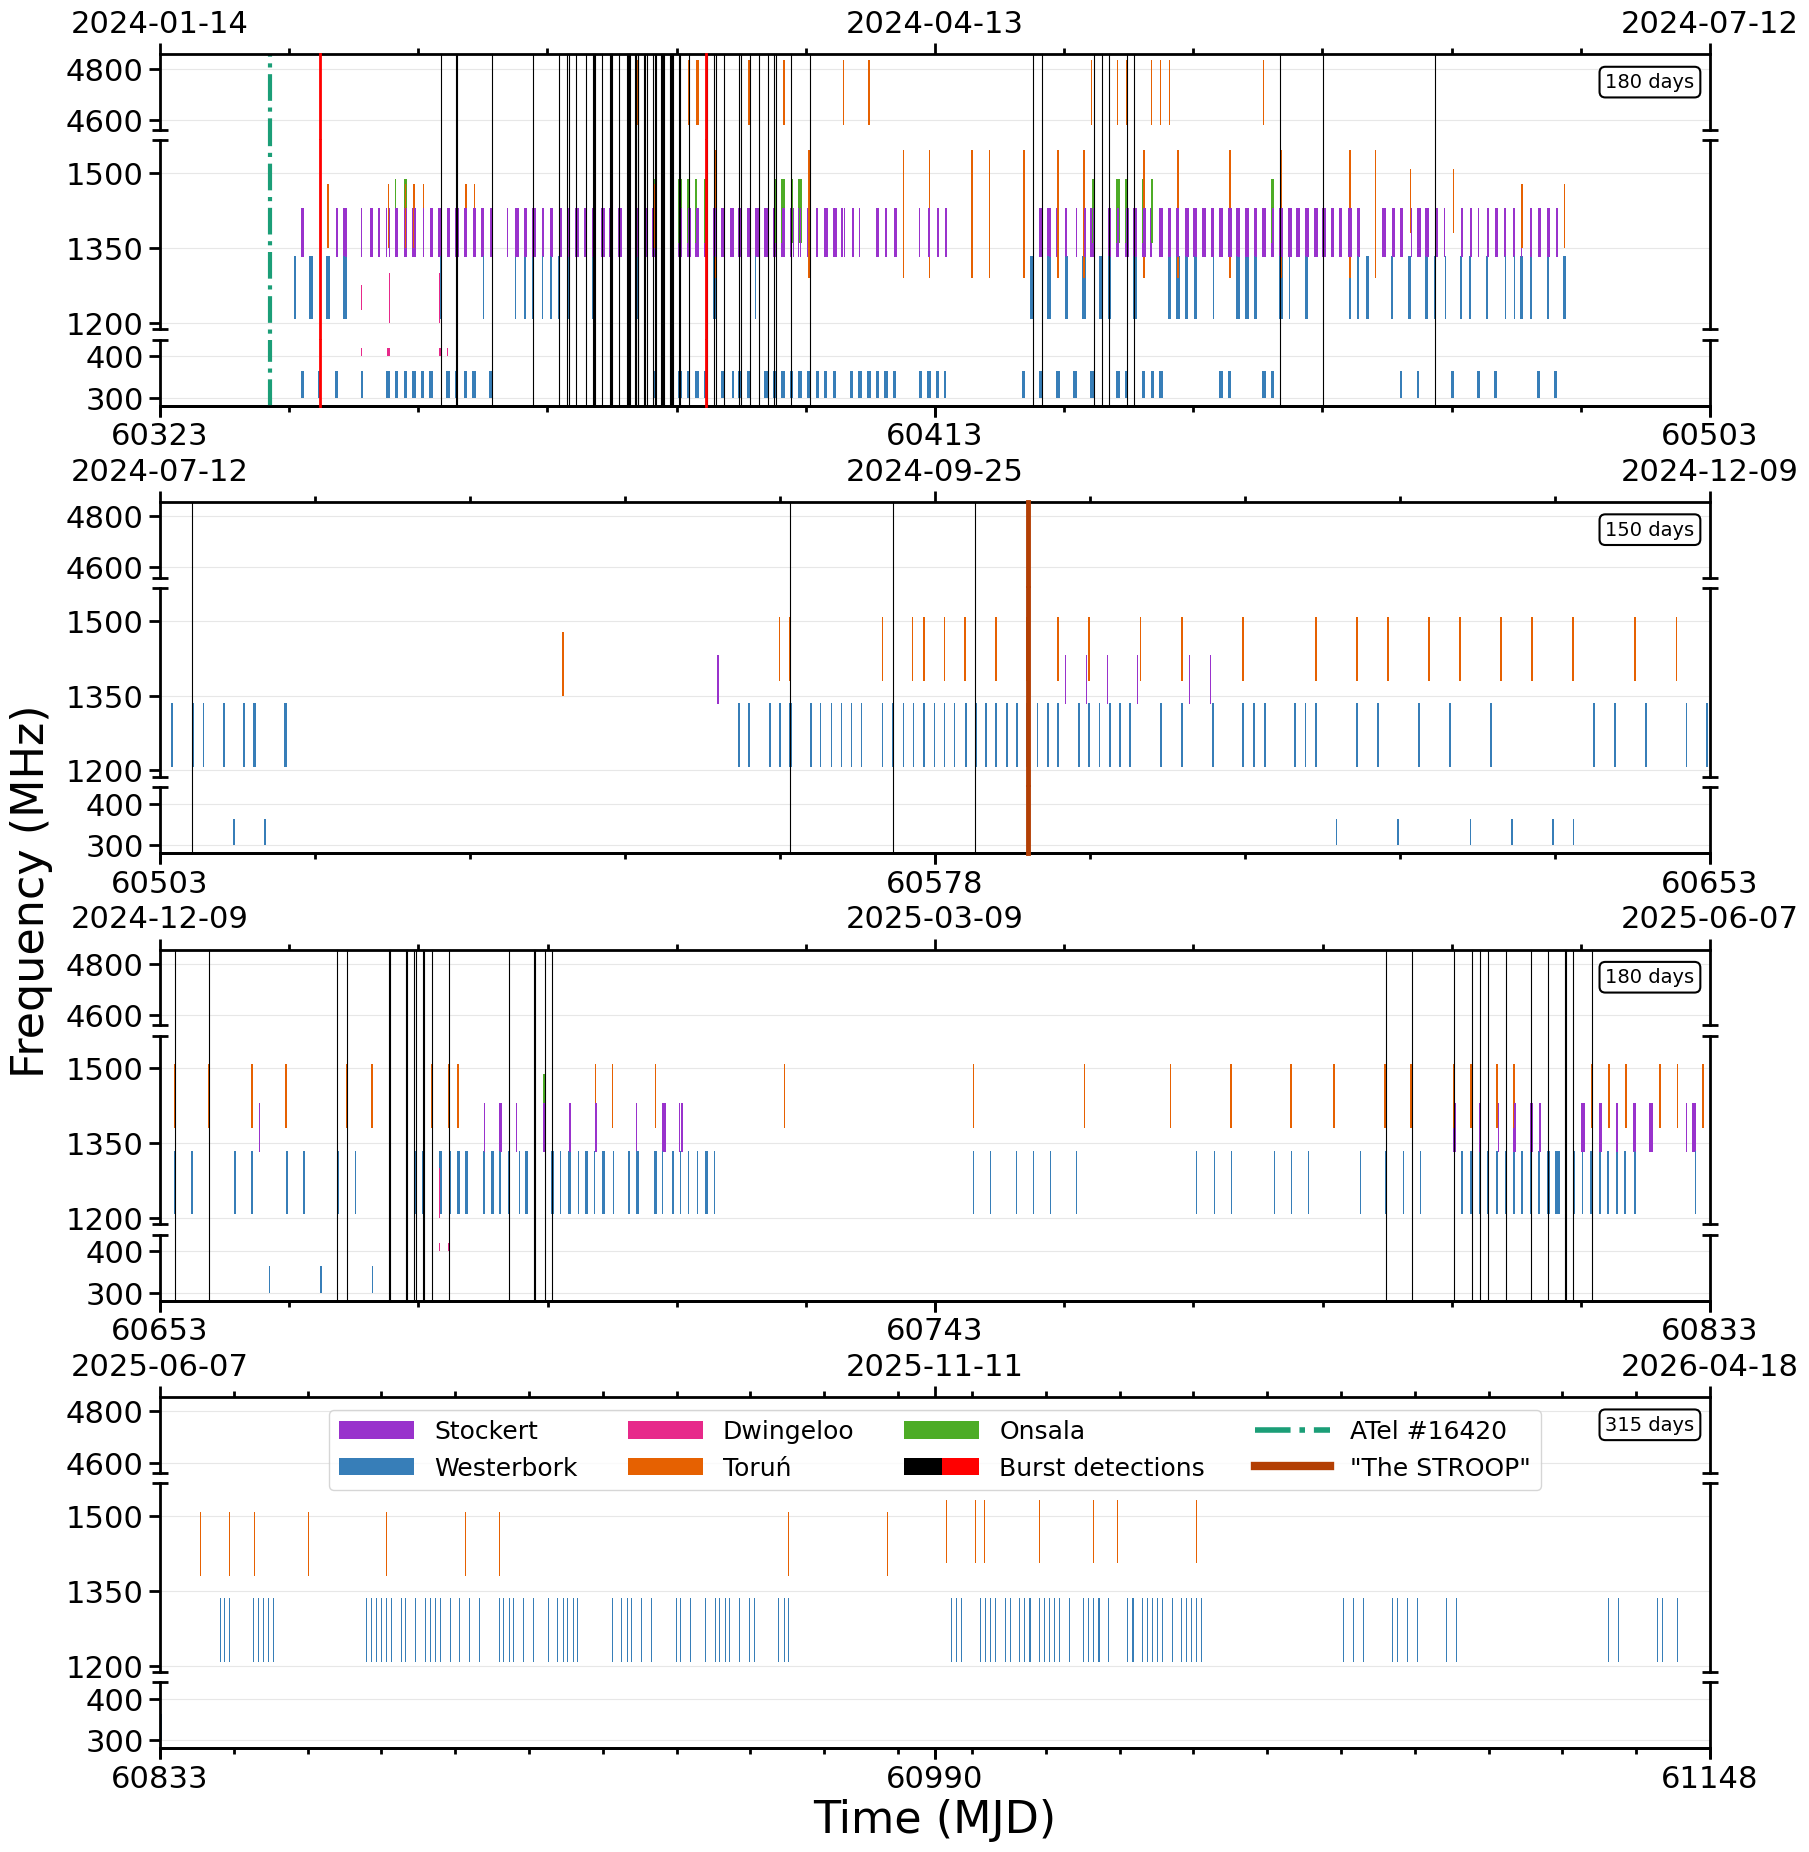

In [8]:
def observing_plot(df_reduced):

    colours = get_station_colors()
    
    # Set figure size
    width, height = 20, 22
    fig, (ax1, ax2, ax3, ax4,
          ax5, ax6, ax7, ax8,
          ax9, ax10, ax11, ax12,
          ax13, ax14, ax15) = plt.subplots(
        15, 1, figsize=(width, height), sharex=False,
        gridspec_kw={'height_ratios': (0.4, 1, 0.35, 0.4,
                                       0.4, 1, 0.35, 0.4,
                                       0.4, 1, 0.35, 0.4,
                                       0.4, 1, 0.35)}
    )
    fig.subplots_adjust(hspace=0)

    # Set spacing and limits
    space = 20
    c_low, c_high = 4580, 4836
    l_low, l_high = 1207, 1546
    c_axes  = [ax1,  ax5,  ax9,  ax13]
    l_axes  = [ax2,  ax6,  ax10, ax14]
    p_axes  = [ax3,  ax7,  ax11, ax15]
    inv_axes = [ax4, ax8,  ax12]

    for ax in c_axes:
        ax.set_ylim(c_low - space, c_high + space)
        ax.set_yticks([4600, 4800])
        ax.spines['top'].set_visible(True)
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(labeltop=True, labelbottom=False, bottom=False, top=True)

    for ax in l_axes:
        ax.set_ylim(l_low - space, l_high + space)
        ax.set_yticks([1200, 1350, 1500])
        ax.spines['top'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(labeltop=False, labelbottom=False, bottom=False, top=False)

    for ax in p_axes:
        ax.set_ylim(300 - space, 420 + space)
        ax.set_yticks([300, 400])
        ax.spines['top'].set_visible(False)
        ax.tick_params(labeltop=False, bottom=False, labelbottom=False, top=False)
        ax.xaxis.tick_bottom()

    for ax in inv_axes:
        ax.set_visible(False)

    # MJD boundaries
    start_mjd = 60323
    bound_1   = 60503
    bound_2   = 60653
    bound_3   = 60833
    end_mjd   = 61148

    # Set x-limits and xticks for each panel manually (no sharex)
    limits = [
        (start_mjd, bound_1),
        (bound_1,   bound_2),
        (bound_2,   bound_3),
        (bound_3,   end_mjd),
    ]

    for ax_c, ax_l, ax_p, (lo, hi) in zip(c_axes, l_axes, p_axes, limits):
        mid = lo + (hi - lo) / 2
        ticks = [lo, mid, hi]
        for ax in [ax_c, ax_l, ax_p]:
            ax.set_xlim(lo, hi)
            ax.set_xticks(ticks)

    # ISO date labels on top of each c_axis
    for ax in c_axes:
        times_top = ax.get_xticks()
        t_t = Time(times_top, format='mjd', scale='utc')
        mjd_isot_t = t_t.to_value('isot', 'date')
        ax.set_xticklabels(mjd_isot_t, rotation=0)

    # Secondary x-axes (MJD labels) on the bottom of each p_axis
    secaxes = []
    for ax_p, ax_c in zip(p_axes, c_axes):
        secax = ax_p.secondary_xaxis('bottom')
        ticks = ax_c.get_xticks()
        secax.set_xticks(ticks)
        secax.set_xticklabels([int(m) for m in ticks])
        secaxes.append(secax)

    secax3, secax7, secax11, secax15 = secaxes

    # Days displayed label in top left of each c_axis
    for ax_c, (lo, hi) in zip(c_axes, limits):
        n_days = int(hi - lo)
        ax_c.text(0.99, 0.76, f'{n_days} days', transform=ax_c.transAxes,
                  fontsize=14, va='top', ha='right', color='k',
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='k', linewidth=1.5))
        
    # Main labels
    size_main_lbl = 32
    secax15.set_xlabel("Time (MJD)", fontsize=size_main_lbl)
    fig.text(0.05, 0.5, 'Frequency (MHz)', va='center', rotation='vertical', fontsize=size_main_lbl)

    # Draw diagonal lines for broken axes
    kwargs = dict(marker=[(-1, 0), (1, 0)], markersize=12,
                  linestyle="none", color='k', mec='k', mew=2, clip_on=False)
    for ax_c, ax_l, ax_p in zip(c_axes, l_axes, p_axes):
        ax_c.plot([0, 1], [0, 0], transform=ax_c.transAxes, **kwargs)
        ax_l.plot([1, 0], [1, 1], transform=ax_l.transAxes, **kwargs)
        ax_l.plot([0, 1], [0, 0], transform=ax_l.transAxes, **kwargs)
        ax_p.plot([1, 0], [1, 1], transform=ax_p.transAxes, **kwargs)

    fig.subplots_adjust(hspace=0.1)

    # Legend
    legend_elements = [
        Patch(facecolor=colours['st'], label='Stockert'),
        Patch(facecolor=colours['wb'], label='Westerbork'),
        Patch(facecolor=colours['dw'], label='Dwingeloo'),
        Patch(facecolor=colours['tr'], label='Toruń'),
        Patch(facecolor=colours['on'], label='Onsala'),
        HalfHalfPatch(label='Burst detections'),
        Line2D([0], [0], color='#1b9e77', linestyle='dashdot', linewidth=4, label='ATel #16420'),
        Line2D([0], [0], color='#b33f04', linestyle='-', linewidth=6, label='"The STROOP"'),
    ]
    bbox = ax13.get_position()
    fig.legend(handles=legend_elements,
               handler_map={HalfHalfPatch: HalfHalfHandler()},
               loc='upper center',
               bbox_to_anchor=(bbox.x0 + bbox.width / 2, bbox.y1),
               fontsize=18,
               ncol=4,
               handlelength=3)

    # Plot observation data
    for i in tqdm(range(len(df_reduced["mjd_start"]))):
        tele        = df_reduced["Telescope"][i]
        mjd_s       = df_reduced["mjd_start"][i]
        low_c       = df_reduced["low_c_l"][i]
        bandwidth   = df_reduced["bandwidth"][i]
        obs_time_d  = df_reduced["rec_time_d"][i]

        if tele == "stk":
            cc = colours['st']
        elif tele == "o8":
            cc = colours['on']
        elif tele == "tr":
            cc = colours['tr']
        elif tele == "wb":
            cc = colours['wb']
        elif tele == "dw":
            cc = colours['dw']

        for ax in [*c_axes, *l_axes, *p_axes]:
            rect = Rectangle((mjd_s, low_c), obs_time_d, height=bandwidth,
                             facecolor=cc, lw=0.0, edgecolor='k')
            ax.add_patch(rect)

   # Burst detection vertical lines
    vline_kwargs = dict(ymax=1, clip_on=False, ls='-', zorder=5)
    #THE STROOP
    special_mjd = 60586.95765262046

    for ax_c, ax_l, ax_p, (lo, hi) in zip(c_axes, l_axes, p_axes, limits):
        bursts = df_mjds[df_mjds['toa'].between(lo, hi)]
        for _, row in bursts.iterrows():
            if abs(row['toa'] - special_mjd) < 1e-6:
                color, lw = '#b33f04', 3.5
            elif row['cent_freq'] < 400:
                color, lw = 'red', 2.0
            else:
                color, lw = 'k', 0.8
            ax_c.axvline(x=row['toa'], ymin=-1.2,  color=color, lw=lw, **vline_kwargs)
            ax_l.axvline(x=row['toa'], ymin=-0.35, color=color, lw=lw, **vline_kwargs)
            ax_p.axvline(x=row['toa'], ymin=0,     color=color, lw=lw, **vline_kwargs)

    chime_atel = [60335.75902777778]
    for burst_mjd in chime_atel:
        ax1.axvline(x=burst_mjd, ymin=-0.2, ymax=1, clip_on=False, ls='dashdot', color='#1b9e77', lw=3)
        ax2.axvline(x=burst_mjd, ymin=-0.2, ymax=1, clip_on=False, ls='dashdot', color='#1b9e77', lw=3)
        ax3.axvline(x=burst_mjd, ymin=0, ymax=1, clip_on=False, ls='dashdot', color='#1b9e77', lw=3)

        # Minor ticks: on c_axes (top) and secaxes (bottom), hidden on l_axes
    for ax_c, secax, (lo, hi) in zip(c_axes, secaxes, limits):
        ticks = np.arange(lo, hi, 15)
        ax_c.tick_params(which='minor', labeltop=False, labelbottom=False, bottom=False, top=True)
        ax_c.xaxis.set_minor_locator(FixedLocator(ticks))
        secax.xaxis.set_minor_locator(FixedLocator(ticks))

    for ax in l_axes:
        ax.xaxis.set_minor_locator(NullLocator())

    # Grid on major ticks only
    for ax in [*c_axes, *l_axes, *p_axes]:
        ax.grid(True, which='major', axis='y', alpha=0.3)
        ax.set_axisbelow(True)

    # Spine width and tick params
    for ax in [*c_axes, *l_axes, *p_axes, *secaxes]:
        for axis in ['top', 'bottom', 'left', 'right']:
            ax.spines[axis].set_linewidth(2)
        ax.tick_params(axis='y', which='major', direction='out', length=8, width=2, labelsize=22)
        ax.tick_params(axis='x', which='major', direction='out', length=8, width=2, labelsize=22)
        ax.tick_params(axis='x', which='minor', direction='out', length=4, width=2, labelsize=22)

    save_name = "observing_plot_r147_V2"
    plt.savefig(f"../plots/{save_name}.pdf", format = 'pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f"../plots/{save_name}.png", facecolor='white', transparent=False, \
                format = 'png',bbox_inches='tight', dpi=300)
    
    plt.show()

observing_plot(df_reduced=df_reduced)